In [1]:
import sys
sys.path.append("../")

In [ ]:
import torch
import numpy as np
import random
import logging
import matplotlib as mpl
import matplotlib.pyplot as plt
from importlib import reload

from qmpsqsc.models import mpsqsc
from qmpsqsc.models import qmps
from qmpsqsc.models.data.utils import flip_sites_in_mps
from qmpsqsc.models.data import (
    LinearSVM,
    svm_hinge_loss,
    svm_accuracy,
    poly2_features,
    train_mpstates_with_svm,
    train_mpsqsc_with_svm,
    train_qmps_with_svm,
)
import qmpsqsc.models.data as mpsdata

mpl.rcParams.update(
    {
        "axes.linewidth": 1.1,
        "lines.linewidth": 2.0,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,
        "font.size": 16,
        "axes.labelsize": 18,
        "legend.fontsize": 15,
        "figure.titlesize": 20,
        "figure.figsize": (10, 6),
        "figure.dpi": 150,
    }
)

COLORS = {
    1: "#0072B2",  # Blue
    2: "#D55E00",  # Vermilion
    4: "#009E73",  # Green
}

logging.basicConfig(
    level=logging.WARNING,  # root stays at INFO (or WARNING)
    format="%(asctime)s - %(name)s - %(levelname)s - %(message)s",
    force=True,
)

project_logger = logging.getLogger("qmpsqsc")
project_logger.setLevel(logging.DEBUG)
# project_logger.propagate = False  # optional: keep our debug output out of root

# Silence TenPy (or any other noisy lib) explicitly:
# logging.getLogger("tenpy").setLevel(logging.WARNING)

reload(mpsqsc)
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)


In [4]:
import torch.nn.functional as F

L = 30
chi = 2
d = 2
ghz = mpsqsc.build_ghz_state(L, d, chi).to(dtype=torch.complex128)
ghz = ghz.normalize()

zghz = ghz.copy()
zghz.As[0][:, 1] = -ghz.As[0][:, 1]

ghz_X_errors = [flip_sites_in_mps(ghz, [i], "X") for i in range(L)]
ghz_Y_errors = [flip_sites_in_mps(ghz, [i], "Y") for i in range(L)]
ghz_Z_errors = [flip_sites_in_mps(ghz, [i], "Z") for i in range(L)]

zghz_X_errors = [flip_sites_in_mps(zghz, [i], "X") for i in range(L)]
zghz_Y_errors = [flip_sites_in_mps(zghz, [i], "Y") for i in range(L)]
zghz_Z_errors = [flip_sites_in_mps(zghz, [i], "Z") for i in range(L)]

allup = mpsqsc.build_classical_state(L, d, [0]*L).to(dtype=torch.complex128)
alldown = mpsqsc.build_classical_state(L, d, [1]*L).to(dtype=torch.complex128)


In [5]:
ghzs_X = mpsqsc.add_mpstates(ghz_X_errors)
ghzs_Y = mpsqsc.add_mpstates(ghz_Y_errors)



zghzs_X = mpsqsc.add_mpstates(zghz_X_errors)
zghzs_Y = mpsqsc.add_mpstates(zghz_Y_errors)


In [6]:
from qmpsqsc.models.mpsqsc.compress import compress_mpstate

ghzs_X, ghzsX_fid = compress_mpstate(ghzs_X, 4, adam_steps=0, n_sweeps=1)
ghzs_Y, ghzsY_fid = compress_mpstate(ghzs_Y, 4, adam_steps=0, n_sweeps=1)

print("fidelities", ghzsX_fid, ghzsY_fid)

zghzs_X, zghzX_fid = compress_mpstate(zghzs_X, 4, adam_steps=0, n_sweeps=1)
zghzs_Y, zghzY_fid = compress_mpstate(zghzs_Y, 4, adam_steps=0, n_sweeps=1)

print("fidelities", zghzX_fid, zghzY_fid)


ghzs = mpsqsc.add_mpstates([ghz, ghzs_X])
ghzs = ghzs.normalize()

ghzs, ghzs_fid = compress_mpstate(ghzs, 6, adam_steps=0, n_sweeps=1)

print("fidelities", ghzs_fid)

zghzs = mpsqsc.add_mpstates([zghz, zghzs_X])
zghzs = zghzs.normalize()

zghzs, zghz_fid = compress_mpstate(zghzs, 6, adam_steps=0, n_sweeps=1)

print("fidelities", zghz_fid)


/Users/keisuke/miniconda3/envs/mpsqsc/lib/python3.11/site-packages/tenpy/networks/mps.py:1629: UserWarning: unit_cell_width is a new argument for MPS and similar classes. It is optional for now, but will become mandatory in a future release. The default value (unit_cell_width=len(sites)) is correct, iff the lattice is a Chain. For other lattices, it is incorrect. It is used for dipolar charges and correlation_function2.
  super().__init__(sites, bc, unit_cell_width)
/Users/keisuke/miniconda3/envs/mpsqsc/lib/python3.11/site-packages/tenpy/algorithms/mps_common.py:2259: UserWarning: VariationalCompression with min_sweeps=max_sweeps: we recommend to set tol_theta_diff=None to avoid overhead
  warnings.warn(
/Users/keisuke/Documents/projects/mps4qsc/notebooks/../qmpsqsc/models/mpsqsc/compress.py:36: ComplexWarning: Casting complex values to real discards the imaginary part
  return res_mps, float(psi_t.overlap(psi))


fidelities (1.0000000000000002+0j) (1.0000000000000009+1.1657341758564144e-15j)
fidelities (0.9999999999999996+0j) (1+1.0364972768961422e-15j)
fidelities (0.9999999999999997+0j)
fidelities (1.0000000000000009+0j)


In [7]:
# LinearSVM, hinge loss helpers, accuracy metrics, and polynomial feature
# maps now come from qmpsqsc.models.data.svm (see imports above).


In [26]:
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "axes.linewidth": 1.1,
    "lines.linewidth": 2.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
})
COLORS = {1: "#0072B2", 2: "#D55E00", 4: "#009E73"}

def plot_loss_accuracy(
    losses,
    accuracies,
    title,
    loss_label="Loss",
    acc_label="Accuracy",
):
    """Nicely styled dual-axis plot for training metrics."""
    if len(losses) == 0 or len(accuracies) == 0:
        print(f"No metrics collected for {title}, skipping plot.")
        return

    steps = np.arange(1, len(losses) + 1)
    loss_color = COLORS.get(1, "#0072B2")
    acc_color = COLORS.get(2, "#D55E00")

    fig, ax1 = plt.subplots(figsize=(11.5, 5.8))

    loss_line = ax1.plot(steps, losses, color=loss_color, label=loss_label, lw=2.4)[0]

    ax1.set_xlabel("Iteration")
    ax1.set_ylabel(loss_label, color=loss_color)
    ax1.tick_params(axis="x", which="both", labelsize=13)
    ax1.tick_params(axis="y", which="both", labelcolor=loss_color)
    ax1.set_xlim(steps[0], steps[-1])
    ax1.margins(x=0.01)

    ax1.grid(True, which="major", color="#d0d0d0", alpha=0.6, linestyle="--")
    ax1.grid(True, which="minor", color="#e8e8e8", alpha=0.5, linestyle=":")

    for spine in ax1.spines.values():
        spine.set_alpha(0.85)

    ax2 = ax1.twinx()
    acc_line = ax2.plot(
        steps,
        accuracies,
        color=acc_color,
        linestyle="--",
        label=acc_label,
    )[0]
    ax2.set_ylabel(acc_label, color=acc_color)
    ax2.tick_params(axis="y", which="both", labelcolor=acc_color)
    ax2.set_ylim(-0.02, 1.02)

    handles = [loss_line, acc_line]
    labels = [loss_label, acc_label]
    ax1.legend(handles, labels, loc="lower right", frameon=False)

    ax1.set_title(title, fontsize=17, pad=12)
    fig.tight_layout()
    plt.show()


In [9]:
svm = LinearSVM(in_dim=5, dtype=torch.float64)  # because phi(V) has dim 3
svm.train()

LinearSVM(
  (linear): Linear(in_features=5, out_features=1, bias=True)
)

In [10]:
data_generator = mpsdata.ghz.create_ghz_rho_batch_qsc(ghz, allup, alldown, 2**6, 0.7, random_flip=True)

In [11]:
ghzs.set_requires_grad(True)
zghzs.set_requires_grad(True)
optimizer = torch.optim.Adam(ghzs.As + zghzs.As, lr=0.001)
optim_svm = torch.optim.Adam(svm.parameters(), lr=0.08)

stage1_losses, stage1_accs = train_mpstates_with_svm(
    positive_state=ghzs,
    negative_state=zghzs,
    data_iterator=data_generator,
    svm=svm,
    mp_optimizer=optimizer,
    svm_optimizer=optim_svm,
    num_steps=50,
    svm_steps=10,
    hinge_c=0.5,
    feature_map=poly2_features,
)


2025-11-24 18:26:27,980 - qmpsqsc.models.data.svm - DEBUG - Starting hybrid training loop: steps=50, svm_steps=10, target_loss=None
2025-11-24 18:26:28,474 - qmpsqsc.models.data.svm - INFO - Hybrid step 1/50 loss=0.354012 acc=0.500
2025-11-24 18:26:28,929 - qmpsqsc.models.data.svm - INFO - Hybrid step 2/50 loss=0.198521 acc=1.000
2025-11-24 18:26:29,483 - qmpsqsc.models.data.svm - INFO - Hybrid step 3/50 loss=0.098511 acc=1.000
2025-11-24 18:26:29,825 - qmpsqsc.models.data.svm - INFO - Hybrid step 4/50 loss=0.023308 acc=1.000
2025-11-24 18:26:30,430 - qmpsqsc.models.data.svm - INFO - Hybrid step 5/50 loss=0.027712 acc=1.000
2025-11-24 18:26:30,785 - qmpsqsc.models.data.svm - INFO - Hybrid step 6/50 loss=0.028666 acc=1.000
2025-11-24 18:26:31,138 - qmpsqsc.models.data.svm - INFO - Hybrid step 7/50 loss=0.027939 acc=1.000
2025-11-24 18:26:31,496 - qmpsqsc.models.data.svm - INFO - Hybrid step 8/50 loss=0.027252 acc=1.000
2025-11-24 18:26:31,853 - qmpsqsc.models.data.svm - INFO - Hybrid st

In [12]:
mps_qsc = mpsqsc.helper.build_qsc_from_mpstates(ghzs, zghzs)
mps_qsc = mps_qsc.truncate_bond_dimension(2)
mps_qsc.set_requires_grad(True)

In [13]:
optimizer = torch.optim.Adam(mps_qsc.As, lr=0.01)
optim_svm = torch.optim.Adam(svm.parameters(), lr=0.01)

stage2_losses, stage2_accs = train_mpsqsc_with_svm(
    model=mps_qsc,
    data_iterator=data_generator,
    svm=svm,
    model_optimizer=optimizer,
    svm_optimizer=optim_svm,
    num_steps=200,
    svm_steps=30,
    hinge_c=0.5,
    feature_map=poly2_features,
)


2025-11-24 18:26:46,134 - qmpsqsc.models.data.svm - DEBUG - Starting hybrid training loop: steps=200, svm_steps=30, target_loss=None
2025-11-24 18:26:46,344 - qmpsqsc.models.data.svm - INFO - Hybrid step 1/200 loss=0.019380 acc=1.000
2025-11-24 18:26:46,504 - qmpsqsc.models.data.svm - INFO - Hybrid step 2/200 loss=0.018974 acc=1.000
2025-11-24 18:26:46,666 - qmpsqsc.models.data.svm - INFO - Hybrid step 3/200 loss=0.210696 acc=0.750
2025-11-24 18:26:46,814 - qmpsqsc.models.data.svm - INFO - Hybrid step 4/200 loss=0.024274 acc=1.000
2025-11-24 18:26:46,984 - qmpsqsc.models.data.svm - INFO - Hybrid step 5/200 loss=0.070866 acc=0.969
2025-11-24 18:26:47,132 - qmpsqsc.models.data.svm - INFO - Hybrid step 6/200 loss=0.100730 acc=0.938
2025-11-24 18:26:47,283 - qmpsqsc.models.data.svm - INFO - Hybrid step 7/200 loss=0.120869 acc=0.922
2025-11-24 18:26:47,430 - qmpsqsc.models.data.svm - INFO - Hybrid step 8/200 loss=0.067103 acc=1.000
2025-11-24 18:26:47,575 - qmpsqsc.models.data.svm - INFO - 

In [14]:
mps_qsc = mps_qsc.canonicalize(truncate=True)
Us, last = qmps.construct_unitary_from_As(mps_qsc.As)
qmps_ghz = qmps.qMPS(L, chi, d, Us=Us, last_unitary=last)
qmps_ghz.set_requires_grad(True)

In [15]:
svm_qmps = svm.clone()

In [16]:
states, labels, errors = next(data_generator)
probs = qmps_ghz.predict(states)[0]
phi_V = poly2_features(probs)
scores = svm_qmps(phi_V)
probs[labels==0].max(dim=-1).values.min(), svm_qmps.linear.weight

(tensor(0.9895, dtype=torch.float64, grad_fn=<MinBackward1>),
 Parameter containing:
 tensor([[ 0.0227,  0.0160, -2.0899,  2.9874, -2.0987]], dtype=torch.float64,
        requires_grad=True))

In [17]:
scores[labels==0]

tensor([-1.0344, -1.0604, -1.0526, -1.0344, -1.0604, -1.0344, -1.0344, -1.0527,
        -1.0678, -1.0344, -1.0604, -1.0604, -1.0574, -1.0604, -0.9864, -1.0603,
        -1.0081, -1.0344, -1.0604, -1.0604, -1.0604, -1.0344, -1.0344, -1.0604,
        -1.0344, -1.0608, -1.0604, -1.0344, -1.0295, -1.0528, -1.0528, -1.0604],
       dtype=torch.float64, grad_fn=<IndexBackward0>)

In [18]:
from qmpsqsc.models.qmps.optimizer import StiefelAdam

optimizer = StiefelAdam(qmps_ghz.unitaries(), lr=0.01)
optim_svm = torch.optim.Adam(svm_qmps.parameters(), lr=0.01)

initial_weight = 0.0

stage3_losses, stage3_accs, stage3_meta = train_qmps_with_svm(
    model=qmps_ghz,
    data_iterator=data_generator,
    svm=svm_qmps,
    model_optimizer=optimizer,
    svm_optimizer=optim_svm,
    num_steps=2000,
    svm_steps=20,
    hinge_c=0.5,
    feature_map=poly2_features,
    # initial_weight=0,
    max_weight=1.0,
    max_weight_loops=100,
    weight_eval_batches=3,
    weight_search_tol=5e-4,
    weight_loss_threshold=0.07,
    weight_search_steps=10,
    target_loss=0.04,
    loss_window=10,
    no_improve_patience=15,
)

print(f"Initial w: {stage3_meta['initial_weight']}")
print(f"Final selected w: {stage3_meta['selected_weight']}")
print(f"Total steps: {stage3_meta['steps']}")
print("Weight loop summary:")
for idx, w in enumerate(stage3_meta.get("all_selected_weights", []), start=1):
    steps = stage3_meta.get("steps_per_loop", [])
    step_count = steps[idx - 1] if idx - 1 < len(steps) else 'n/a'
    print(f"  Loop {idx}: w={w:.3f}, steps={step_count}")
    eval_logs = stage3_meta.get("weight_evaluations_history", [])
    if idx - 1 < len(eval_logs):
        for ev_w, ev_loss in eval_logs[idx - 1]:
            print(f"    eval -> w={ev_w:.3f}, loss={ev_loss:.4f}")



2025-11-24 18:27:17,523 - qmpsqsc.models.data.svm - INFO - Starting qMPS hybrid training with weight target=1.000 (initial=0.000)
2025-11-24 18:27:17,523 - qmpsqsc.models.data.svm - DEBUG - Evaluating qMPS loss over 3 batches (hinge_c=0.5)
2025-11-24 18:27:18,398 - qmpsqsc.models.data.svm - DEBUG - Evaluating qMPS loss over 3 batches (hinge_c=0.5)
2025-11-24 18:27:19,246 - qmpsqsc.models.data.svm - DEBUG - Evaluating qMPS loss over 3 batches (hinge_c=0.5)
2025-11-24 18:27:20,091 - qmpsqsc.models.data.svm - DEBUG - Weight search: left=0.000000, right=0.499999, mid=0.499999, mid_loss=0.415771
2025-11-24 18:27:20,092 - qmpsqsc.models.data.svm - DEBUG - Evaluating qMPS loss over 3 batches (hinge_c=0.5)
2025-11-24 18:27:20,953 - qmpsqsc.models.data.svm - DEBUG - Weight search: left=0.000000, right=0.250000, mid=0.250000, mid_loss=0.306094
2025-11-24 18:27:20,953 - qmpsqsc.models.data.svm - DEBUG - Evaluating qMPS loss over 3 batches (hinge_c=0.5)
2025-11-24 18:27:21,799 - qmpsqsc.models.dat

Initial w: 0.0
Final selected w: 0.999999
Total steps: 381
Weight loop summary:
  Loop 1: w=0.014, steps=11
    eval -> w=0.000, loss=0.0186
    eval -> w=1.000, loss=0.5144
    eval -> w=0.500, loss=0.4158
    eval -> w=0.250, loss=0.3061
    eval -> w=0.125, loss=0.2107
    eval -> w=0.062, loss=0.1733
    eval -> w=0.031, loss=0.1186
    eval -> w=0.016, loss=0.0813
    eval -> w=0.008, loss=0.0525
    eval -> w=0.012, loss=0.0589
    eval -> w=0.014, loss=0.0688
    eval -> w=0.015, loss=0.0808
  Loop 2: w=0.034, steps=29
    eval -> w=0.014, loss=0.0399
    eval -> w=1.000, loss=0.5235
    eval -> w=0.507, loss=0.4006
    eval -> w=0.260, loss=0.2456
    eval -> w=0.137, loss=0.1626
    eval -> w=0.075, loss=0.1125
    eval -> w=0.044, loss=0.0775
    eval -> w=0.029, loss=0.0547
    eval -> w=0.037, loss=0.0809
    eval -> w=0.033, loss=0.0510
    eval -> w=0.035, loss=0.0703
    eval -> w=0.034, loss=0.0549
  Loop 3: w=0.079, steps=61
    eval -> w=0.034, loss=0.0381
    eval ->

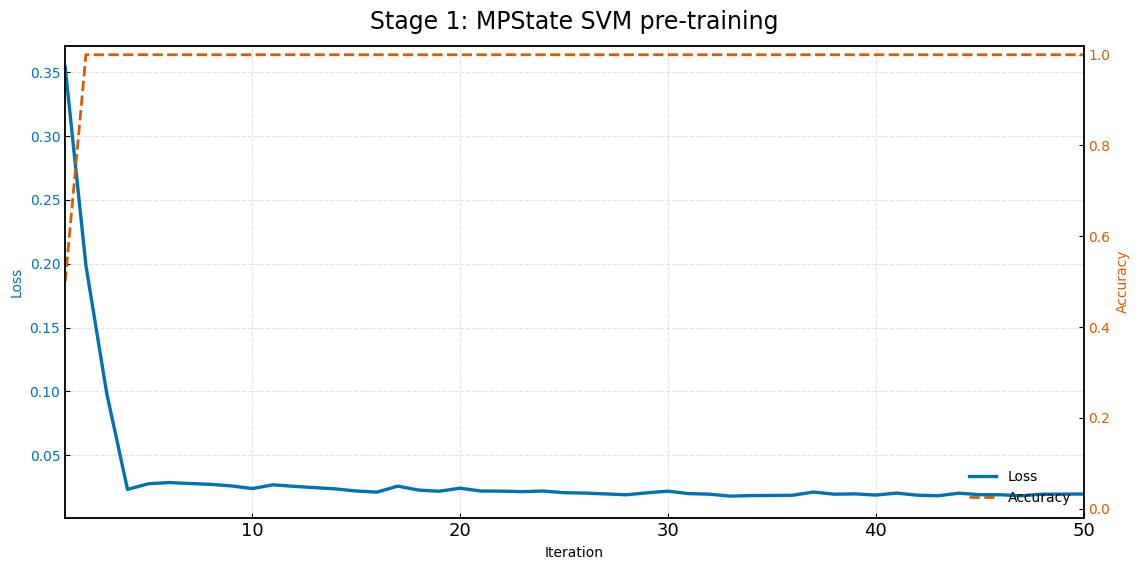

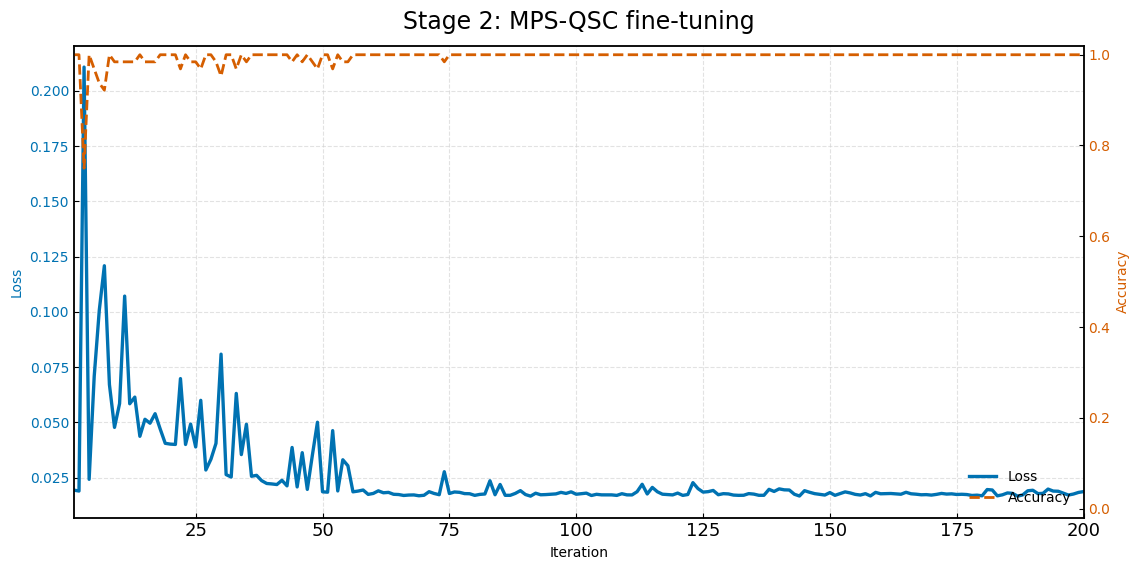

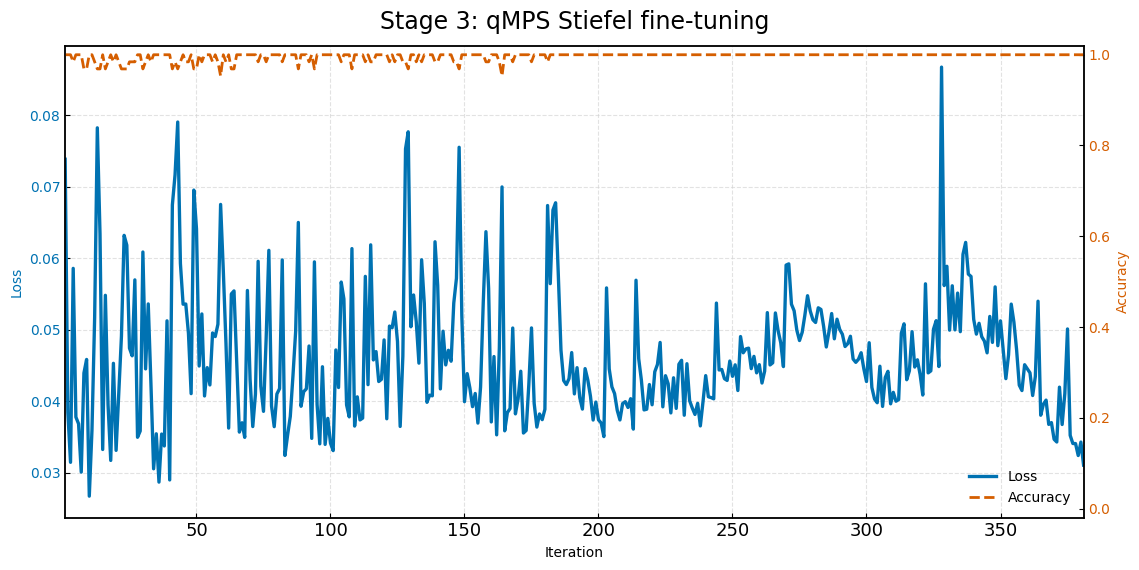

In [27]:
plot_loss_accuracy(stage1_losses, stage1_accs, "Stage 1: MPState SVM pre-training")
plot_loss_accuracy(stage2_losses, stage2_accs, "Stage 2: MPS-QSC fine-tuning")
plot_loss_accuracy(stage3_losses, stage3_accs, "Stage 3: qMPS Stiefel fine-tuning")
